# Inference — Confident-match model on a labeled pairs test set

Load a **saved `.pkl`** (you choose which) from the *confident-match* family and score it on a
labeled **pairs** dataset — by default the synthetic set
`data/synthetic labels/synthetic_test_v3.csv` (`label`: `1` = match, `0` = not-match).
**No training happens here.**

**Scope.** Uses the production `V3FeatureBuilder` (the 12 v3 features), so it serves the
**v3-feature family**: `ambiguous_v3`, `ambiguous_v4`, and the exported `ml_matcher` artifact
(`MatchProbabilityAdapter`). Models on a different feature set are out of scope.

**No ambiguous column.** The synthetic labels are only match / not-match. A confident-match model
separates *confident match* from *everything else*; with no ambiguous pairs present, "everything
else" is just the non-matches, so we evaluate the model's `P(confident match)` directly as a
match-vs-not-match score. Genuine matches the model considers *hard/ambiguous* will score low and
read as errors here — that is expected and informative, not a bug.

## 1. Configuration — pick the model + threshold

In [7]:
# --- Choose the model artifact (.pkl). Leave as None to auto-pick the newest under models/. ---
MODEL_PATH = None

# --- How to read predict_proba(X)[:, 1] for this artifact ---
#   'auto'         : MatchProbabilityAdapter -> 'adapter'; any other/raw model -> 'raw_notmatch'
#   'adapter'      : exported ml_matcher .pkl (MatchProbabilityAdapter) -> col 1 = P(confident match)
#   'raw_match'    : raw LGBM whose class 1 = match (e.g. base pair_classifier_lightgbm_v1)
#   'raw_notmatch' : raw LGBM whose class 1 = ambiguous/not-confident-match (raw ambiguous v3/v4)
MODEL_KIND = 'auto'

# Predict 'match' when P(confident match) >= THRESHOLD.
# 0.70 is the serving auto_merge operating point (EMPI_ML_AUTO_MERGE_THRESHOLD); 0.50 is a neutral
# match-vs-not-match cut. The threshold sweep (§6) shows the whole curve.
THRESHOLD = 0.70

# Test set (a pairs CSV with _l/_r suffixed cleaned columns + a `label` column).
SYNTHETIC_REL = 'synthetic_data/synthetic_test_v3.csv'

In [8]:
import sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
)


def _find_service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / 'data').is_dir() and (d / 'src').is_dir():
            return d
    raise FileNotFoundError('could not locate empi-service/ (no ancestor has data/ + src/)')


SERVICE_ROOT = _find_service_root(Path.cwd())
if str(SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVICE_ROOT))
DATA_DIR = SERVICE_ROOT / 'data'

# Production feature builder + the adapter class (needed for joblib to unpickle the artifact).
from src.models.ml_matcher.lightgbm_v3 import V3FeatureBuilder, MatchProbabilityAdapter, FEATURE_COLS
print('service root :', SERVICE_ROOT)
print('features     :', FEATURE_COLS)

service root : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
features     : ['sound_first', 'sound_last', 'cmp_street_num', 'sim_jw_first', 'sim_jw_last', 'sim_jw_middle', 'sim_lev_email', 'sim_lev_address1', 'addr_token_jaccard', 'ssn_digit_frac', 'sim_dob', 'sim_phones']


In [9]:
# Prefer this notebook's own model family (models/ml/), then fall back to all of models/.
PREFERRED_SUBDIR = 'ml'   # confident-match artifacts (MatchProbabilityAdapter) live here


def _looks_corrupt(p: Path) -> bool:
    """True if the file is empty or begins with NUL bytes — not a valid pickle stream.
    A zero-filled/truncated copy is the usual cause of joblib's cryptic `KeyError: 0`."""
    try:
        with open(p, 'rb') as fh:
            head = fh.read(16)
    except OSError:
        return True
    return len(head) == 0 or set(head) == {0}


available = sorted((SERVICE_ROOT / 'models').rglob('*.pkl'))
print('available .pkl artifacts under models/  (x = corrupt/empty):')
for p in available:
    flag = 'x' if _looks_corrupt(p) else 'ok'
    print(f'  [{flag}] {p.relative_to(SERVICE_ROOT)}  ({p.stat().st_size} bytes)')
if not available:
    print('  (none — export a model first, or set MODEL_PATH to a .pkl elsewhere)')

if MODEL_PATH is None:
    preferred = [p for p in available if p.parent.name == PREFERRED_SUBDIR]
    pool = [p for p in (preferred or available) if not _looks_corrupt(p)]
    if not pool:
        raise FileNotFoundError(
            f'no usable .pkl found (looked in models/{PREFERRED_SUBDIR} first, then all of models/). '
            'Files are missing or corrupt (all-zero bytes) — re-copy a valid model artifact, or set '
            'MODEL_PATH explicitly.')
    where = f'models/{PREFERRED_SUBDIR}' if preferred else 'models/'
    MODEL_PATH = max(pool, key=lambda p: p.stat().st_mtime)
    print(f'\nMODEL_PATH not set -> auto-picked newest valid in {where}: '
          f'{MODEL_PATH.relative_to(SERVICE_ROOT)}')

MODEL_PATH = Path(MODEL_PATH)
assert MODEL_PATH.exists(), f'MODEL_PATH does not exist: {MODEL_PATH}'
if _looks_corrupt(MODEL_PATH):
    raise ValueError(
        f'{MODEL_PATH} is empty or all-zero bytes — the model file is corrupt, not a valid pickle. '
        'Re-copy/regenerate it (a truncated or zero-filled transfer is the usual cause).')
print('using model :', MODEL_PATH)

available .pkl artifacts under models/  (x = corrupt/empty):
  [ok] models\ml\ml_model_20260719T141543Z.pkl  (733302 bytes)
  [ok] models\ml\ml_model_20260721T163138Z.pkl  (848294 bytes)
  [ok] models\nonmatch_gate\nonmatch_gate_20260721T160717Z.pkl  (319556 bytes)

MODEL_PATH not set -> auto-picked newest valid in models/ml: models\ml\ml_model_20260721T163138Z.pkl
using model : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\models\ml\ml_model_20260721T163138Z.pkl


## 2. Load the test set and reshape to (records + candidate pairs)
The CSV stores each pair inline with `_l`/`_r` suffixes. `V3FeatureBuilder` expects a **records**
table (one row per PATID) plus a **candidate-pairs** table (`PATID_A`, `PATID_B`), so we split the
two sides back out. Phones are space-separated here, so we parse them into real sets (the builder
consumes native sets directly).

In [10]:
SYNTHETIC_PATH = DATA_DIR / SYNTHETIC_REL
raw = pd.read_csv(SYNTHETIC_PATH, dtype=str)   # dtype=str preserves leading zeros (SSN/ZIP/PATID)
raw['label'] = raw['label'].astype(int)
print('test pairs:', len(raw))
print('label distribution (1=match, 0=not-match):')
print(raw['label'].value_counts())

# Columns V3FeatureBuilder reads (base names).
BASE_COLS = ['FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean',
             'SSN_clean', 'Email_clean', 'AddressLine1_clean', 'Phones_set']


def _phoneset(s):
    """Space- or comma-separated phone string -> set of numbers (also handles the legacy {..} form)."""
    if not isinstance(s, str):
        return set()
    s = s.strip().strip('{}[]').replace("'", '').replace('"', '')
    return {p for p in re.split(r'[,\s]+', s) if p}


def _side_records(suffix, patid_col):
    out = pd.DataFrame({'PATID': raw[patid_col].astype(str)})
    for c in BASE_COLS:
        col = f'{c}_{suffix}'
        out[c] = raw[col] if col in raw.columns else np.nan
    return out


recs = pd.concat([_side_records('l', 'PATID_A'), _side_records('r', 'PATID_B')], ignore_index=True)
recs = recs.drop_duplicates('PATID', keep='first').reset_index(drop=True)
recs['Phones_set'] = recs['Phones_set'].map(_phoneset)

candidate_pairs = raw[['PATID_A', 'PATID_B']].astype(str).copy()
print('\nunique records:', len(recs), '| candidate pairs:', len(candidate_pairs))

test pairs: 10000
label distribution (1=match, 0=not-match):
label
0    8000
1    2000
Name: count, dtype: int64

unique records: 20000 | candidate pairs: 10000


## 3. Build features (production `V3FeatureBuilder`)

In [11]:
feat = V3FeatureBuilder().build_features(candidate_pairs, recs)
X = feat[FEATURE_COLS]
print('feature matrix:', X.shape)
print('NaN fraction per feature:')
display(X.isna().mean().round(3).to_frame('pct_missing'))
X.head()

feature matrix: (10000, 12)
NaN fraction per feature:


,pct_missing
sound_first,0.000
sound_last,0.000
cmp_street_num,0.000
sim_jw_first,0.000
sim_jw_last,0.000
sim_jw_middle,0.931
sim_lev_email,0.864
sim_lev_address1,0.052
addr_token_jaccard,0.052
ssn_digit_frac,0.956


,sound_first,sound_last,cmp_street_num,sim_jw_first,sim_jw_last,sim_jw_middle,sim_lev_email,sim_lev_address1,addr_token_jaccard,ssn_digit_frac,sim_dob,sim_phones
0,different,same,missing,0.511905,1.000000,NaN,NaN,NaN,NaN,NaN,1.000,0.600000
1,different,different,different,0.527778,0.467320,NaN,NaN,0.2,0.0,NaN,1.000,0.677778
2,different,different,same,0.533333,0.466667,NaN,NaN,1.0,1.0,NaN,0.375,0.622222
3,different,different,same,0.502646,0.000000,NaN,NaN,1.0,1.0,NaN,1.000,0.516667
4,different,same,same,0.722222,1.000000,NaN,NaN,1.0,1.0,NaN,0.750,0.566667


## 4. Load the model and score
`p_match = P(confident match)`, computed from `predict_proba` according to `MODEL_KIND`.

In [12]:
loaded = joblib.load(MODEL_PATH)

kind = MODEL_KIND
if kind == 'auto':
    kind = 'adapter' if isinstance(loaded, MatchProbabilityAdapter) else 'raw_notmatch'
    print(f"MODEL_KIND='auto' -> detected '{kind}'")
    if kind == 'raw_notmatch':
        print("  (assuming a raw ambiguous v3/v4 model: class 1 = not-confident-match.\n"
              "   If this is the base match model instead, set MODEL_KIND='raw_match'.)")
assert kind in ('adapter', 'raw_match', 'raw_notmatch'), f'bad MODEL_KIND: {kind}'

proba1 = np.asarray(loaded.predict_proba(X))[:, 1]
p_match = proba1 if kind in ('adapter', 'raw_match') else 1.0 - proba1

y_true = raw['label'].to_numpy()                 # 1 = match, 0 = not-match
y_pred = (p_match >= THRESHOLD).astype(int)
print(f"scored {len(p_match)} pairs | P(match): min={p_match.min():.3f} "
      f"mean={p_match.mean():.3f} max={p_match.max():.3f}")

MODEL_KIND='auto' -> detected 'adapter'
scored 10000 pairs | P(match): min=0.000 mean=0.212 max=1.000


## 5. Evaluation — classification report + confusion matrix

Model : ml_model_20260721T163138Z.pkl   (kind=adapter)
Threshold (predict match if P(match) >= t): 0.7

               precision    recall  f1-score   support

not-match (0)      0.925     0.950     0.937      8000
    match (1)      0.774     0.692     0.731      2000

     accuracy                          0.898     10000
    macro avg      0.850     0.821     0.834     10000
 weighted avg      0.895     0.898     0.896     10000

ROC AUC : 0.9474
PR  AUC : 0.8565


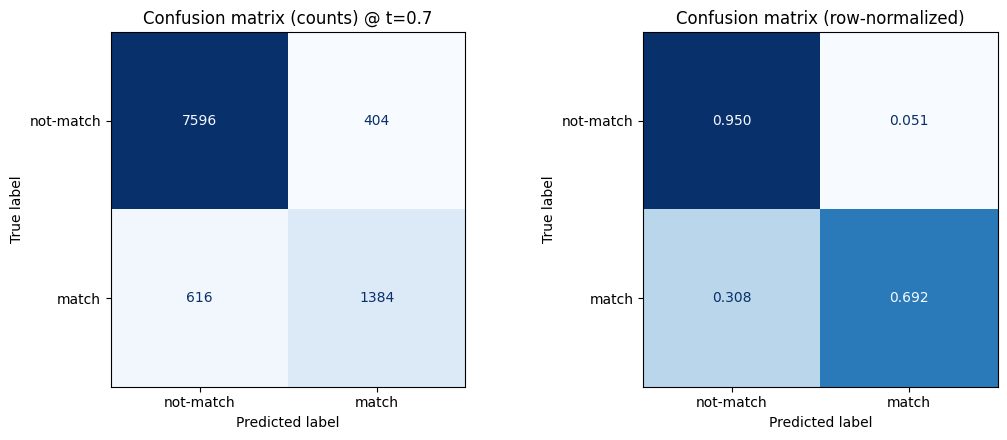

In [13]:
print(f'Model : {MODEL_PATH.name}   (kind={kind})')
print(f'Threshold (predict match if P(match) >= t): {THRESHOLD}\n')
print(classification_report(y_true, y_pred, target_names=['not-match (0)', 'match (1)'], digits=3))
print(f'ROC AUC : {roc_auc_score(y_true, p_match):.4f}')
print(f'PR  AUC : {average_precision_score(y_true, p_match):.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['not-match', 'match']
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=labels).plot(
    ax=ax[0], colorbar=False, cmap='Blues')
ax[0].set_title(f'Confusion matrix (counts) @ t={THRESHOLD}')
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, normalize='true'), display_labels=labels).plot(
    ax=ax[1], colorbar=False, cmap='Blues', values_format='.3f')
ax[1].set_title('Confusion matrix (row-normalized)')
plt.tight_layout(); plt.show()

## 6. Threshold sweep + ROC / PR curves
Precision/recall of the **match** class across thresholds, so the operating point can be chosen
against the tolerable false-merge rate.

,threshold,pred_match_frac,match_precision,match_recall,match_f1,accuracy
0,0.1,0.2926,0.5728,0.8380,0.6805,0.8426
1,0.2,0.2616,0.5734,0.7500,0.6499,0.8384
2,0.3,0.2406,0.6043,0.7270,0.6600,0.8502
3,0.4,0.2222,0.6404,0.7115,0.6741,0.8624
4,0.5,0.2086,0.6740,0.7030,0.6882,0.8726
5,0.6,0.1939,0.7184,0.6965,0.7073,0.8847
6,0.7,0.1788,0.7740,0.6920,0.7307,0.8980
7,0.8,0.1554,0.8578,0.6665,0.7501,0.9112
8,0.9,0.1274,0.9631,0.6135,0.7495,0.9180


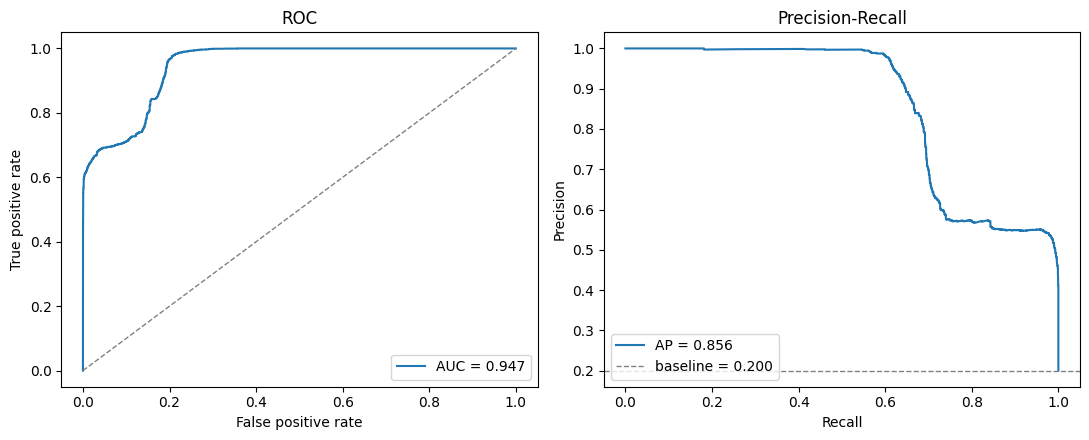

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score
rows = []
for thr in np.round(np.arange(0.1, 0.95, 0.1), 2):
    pred = (p_match >= thr).astype(int)
    rows.append({
        'threshold': thr,
        'pred_match_frac': pred.mean(),
        'match_precision': precision_score(y_true, pred, zero_division=0),
        'match_recall': recall_score(y_true, pred, zero_division=0),
        'match_f1': f1_score(y_true, pred, zero_division=0),
        'accuracy': (pred == y_true).mean(),
    })
display(pd.DataFrame(rows).round(4))

fpr, tpr, _ = roc_curve(y_true, p_match)
prec, rec, _ = precision_recall_curve(y_true, p_match)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, p_match):.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey', lw=1)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC'); ax[0].legend(loc='lower right')
ax[1].plot(rec, prec, label=f'AP = {average_precision_score(y_true, p_match):.3f}')
ax[1].axhline(y_true.mean(), ls='--', color='grey', lw=1, label=f'baseline = {y_true.mean():.3f}')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall'); ax[1].legend(loc='lower left')
plt.tight_layout(); plt.show()

## 7. Breakdown by `case_type`
The synthetic set tags each pair with a `case_type` (`M-*` = match scenarios, `NM-*` = non-match
scenarios). Mean `P(match)` and accuracy per family, plus the hardest individual case types.

In [15]:
ev = pd.DataFrame({
    'case_type': raw.get('case_type', pd.Series(['?'] * len(raw))),
    'label': y_true, 'p_match': p_match, 'pred': y_pred,
})
ev['family'] = ev['case_type'].astype(str).str.split('-').str[0]      # 'M' or 'NM'
ev['correct'] = (ev['pred'] == ev['label'])

print('By family:')
display(ev.groupby('family').agg(n=('label', 'size'), mean_p_match=('p_match', 'mean'),
                                 accuracy=('correct', 'mean')).round(4))

print('Hardest 12 case types (lowest accuracy, min 10 pairs):')
g = ev.groupby('case_type').agg(n=('label', 'size'), label=('label', 'first'),
                                mean_p_match=('p_match', 'mean'), accuracy=('correct', 'mean'))
display(g[g['n'] >= 10].sort_values('accuracy').head(12).round(4))

By family:


,n,mean_p_match,accuracy
family,,,
M,1960,0.7079,0.6857
NM,8000,0.0860,0.9495
POL,40,0.9995,1.0000


Hardest 12 case types (lowest accuracy, min 10 pairs):


,n,label,mean_p_match,accuracy
case_type,,,,
M-NAME-02,44,1,0.2535,0.0455
M-NAME-14,43,1,0.2464,0.2093
M-L4-04,75,1,0.3715,0.2667
M-NAME-04,44,1,0.2969,0.2955
M-MIX-01,43,1,0.3237,0.3023
M-NAME-11,43,1,0.3662,0.3256
M-NAME-16,43,1,0.3645,0.3488
M-NAME-10,43,1,0.3794,0.3488
M-L4-02,75,1,0.4443,0.3600
